<a href="https://colab.research.google.com/github/KipkuruiRonald/colab-notebook/blob/main/RealExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CASE STUDY 1: TITANIC SURVIVAL ANALYSIS
Dataset shape: (891, 12)

--- Missing Data ---
          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


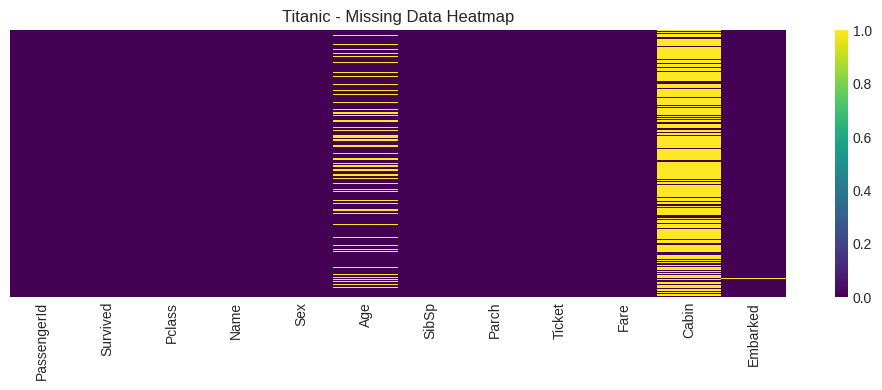


--- Survival Rates ---
Survival by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Survival by Fare Bracket:
Fare_Bracket
Low            19.730942
Medium-Low     30.357143
Medium-High    45.495495
High           58.108108
Name: Survived, dtype: float64

--- Outlier Detection ---
Age outliers: 11 passengers (1.23%)
Fare outliers: 116 passengers (13.02%)


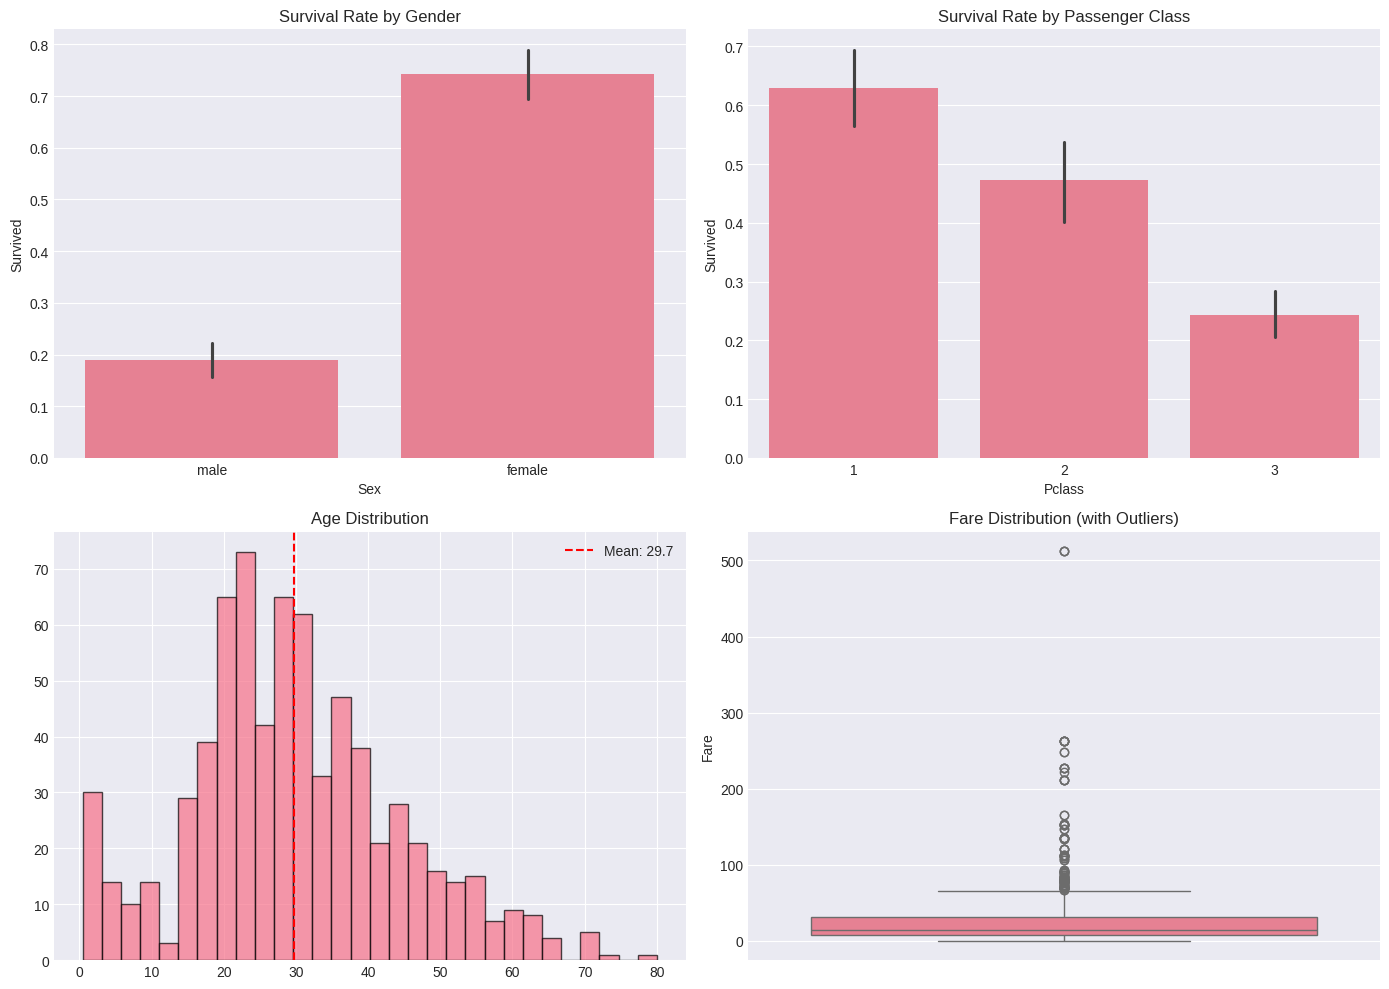

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("CASE STUDY 1: TITANIC SURVIVAL ANALYSIS")
print("="*60)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

print(f"Dataset shape: {titanic_df.shape}")

print("\n--- Missing Data ---")
missing_data = titanic_df.isnull().sum()
missing_percentage = (titanic_df.isnull().sum() / len(titanic_df)) * 100
missing_summary = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percentage})
print(missing_summary[missing_summary['Missing Values'] > 0])

plt.figure(figsize=(10, 4))
sns.heatmap(titanic_df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Titanic - Missing Data Heatmap')
plt.tight_layout()
plt.show()

print("\n--- Survival Rates ---")
survival_by_gender = titanic_df.groupby('Sex')['Survived'].mean() * 100
print(f"Survival by Gender:\n{survival_by_gender}")

survival_by_class = titanic_df.groupby('Pclass')['Survived'].mean() * 100
print(f"\nSurvival by Passenger Class:\n{survival_by_class}")

titanic_df['Fare_Bracket'] = pd.qcut(titanic_df['Fare'].fillna(titanic_df['Fare'].median()), 4,
                                      labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
survival_by_fare = titanic_df.groupby('Fare_Bracket', observed=False)['Survived'].mean() * 100
print(f"\nSurvival by Fare Bracket:\n{survival_by_fare}")

print("\n--- Outlier Detection ---")
Q1_age = titanic_df['Age'].quantile(0.25)
Q3_age = titanic_df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
age_outliers = titanic_df[(titanic_df['Age'] < (Q1_age - 1.5 * IQR_age)) |
                          (titanic_df['Age'] > (Q3_age + 1.5 * IQR_age))]
print(f"Age outliers: {len(age_outliers)} passengers ({len(age_outliers)/len(titanic_df)*100:.2f}%)")

Q1_fare = titanic_df['Fare'].quantile(0.25)
Q3_fare = titanic_df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
fare_outliers = titanic_df[(titanic_df['Fare'] < (Q1_fare - 1.5 * IQR_fare)) |
                           (titanic_df['Fare'] > (Q3_fare + 1.5 * IQR_fare))]
print(f"Fare outliers: {len(fare_outliers)} passengers ({len(fare_outliers)/len(titanic_df)*100:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=titanic_df, x='Sex', y='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Rate by Gender')
sns.barplot(data=titanic_df, x='Pclass', y='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Passenger Class')
axes[1, 0].hist(titanic_df['Age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(titanic_df['Age'].mean(), color='red', linestyle='dashed',
                   label=f"Mean: {titanic_df['Age'].mean():.1f}")
axes[1, 0].set_title('Age Distribution')
axes[1, 0].legend()
sns.boxplot(data=titanic_df, y='Fare', ax=axes[1, 1])
axes[1, 1].set_title('Fare Distribution (with Outliers)')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("CASE STUDY 2: AIRBNB PRICE ANALYSIS")
print("="*60)

try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'kagglehub'])
    import kagglehub

path = kagglehub.dataset_download("venkatreddykonasani/ab-nyc-2019csv")
import os
for file in os.listdir(path):
    if file.endswith('.csv'):
        airbnb_df = pd.read_csv(os.path.join(path, file))
        break

print(f"Dataset shape: {airbnb_df.shape}")

print("\n--- Price Distribution ---")
price_by_neighbourhood = airbnb_df.groupby('neighbourhood_group')['price'].describe()
print("\nPrice by Neighbourhood Group:")
print(price_by_neighbourhood)

price_by_room_type = airbnb_df.groupby('room_type')['price'].describe()
print("\nPrice by Room Type:")
print(price_by_room_type)

print("\n--- Outlier Detection ---")
Q1_price = airbnb_df['price'].quantile(0.25)
Q3_price = airbnb_df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
price_outliers = airbnb_df[(airbnb_df['price'] < (Q1_price - 1.5 * IQR_price)) |
                           (airbnb_df['price'] > (Q3_price + 1.5 * IQR_price))]
print(f"Price outliers: {len(price_outliers)} listings ({len(price_outliers)/len(airbnb_df)*100:.2f}%)")

Q1_avail = airbnb_df['availability_365'].quantile(0.25)
Q3_avail = airbnb_df['availability_365'].quantile(0.75)
IQR_avail = Q3_avail - Q1_avail
avail_outliers = airbnb_df[(airbnb_df['availability_365'] < (Q1_avail - 1.5 * IQR_avail)) |
                           (airbnb_df['availability_365'] > (Q3_avail + 1.5 * IQR_avail))]
print(f"Availability outliers: {len(avail_outliers)} listings ({len(avail_outliers)/len(airbnb_df)*100:.2f}%)")

print(f"\nCorrelation between reviews and price: {airbnb_df['number_of_reviews'].corr(airbnb_df['price']):.3f}")

airbnb_df['review_category'] = pd.cut(airbnb_df['number_of_reviews'],
                                       bins=[-1, 0, 10, 50, 100, airbnb_df['number_of_reviews'].max()],
                                       labels=['No Reviews', 'Low (1-10)', 'Medium (11-50)', 'High (51-100)', 'Very High (>100)'])
avg_price_by_reviews = airbnb_df.groupby('review_category')['price'].mean()
print("\nAverage price by review category:")
print(avg_price_by_reviews)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=airbnb_df, x='neighbourhood_group', y='price', ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution by Neighbourhood')
axes[0, 0].set_yscale('log')
axes[0, 0].tick_params(axis='x', rotation=45)
sns.boxplot(data=airbnb_df, x='room_type', y='price', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution by Room Type')
axes[0, 1].set_yscale('log')
axes[1, 0].scatter(airbnb_df['number_of_reviews'], airbnb_df['price'], alpha=0.3, s=1)
axes[1, 0].set_xlabel('Number of Reviews')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('Price vs Number of Reviews')
axes[1, 0].set_yscale('log')
airbnb_df['availability_365'].hist(bins=50, ax=axes[1, 1], edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Availability Distribution')
axes[1, 1].set_xlabel('Days Available per Year')
plt.tight_layout()
plt.show()

CASE STUDY 2: AIRBNB PRICE ANALYSIS


100%|██████████| 2.29M/2.29M [00:00<00:00, 131MB/s]

Extracting files...


Dataset shape: (48895, 16)

--- Price Distribution ---

Price by Neighbourhood Group:
                       count        mean         std   min   25%    50%  \
neighbourhood_group                                                       
Bronx                 1091.0   87.496792  106.709349   0.0  45.0   65.0   
Brooklyn             20104.0  124.383207  186.873538   0.0  60.0   90.0   
Manhattan            21661.0  196.875814  291.383183   0.0  95.0  150.0   
Queens                5666.0   99.517649  167.102155  10.0  50.0   75.0   
Staten Island          373.0  114.812332  277.620403  13.0  50.0   75.0   

                       75%      max  
neighbourhood_group                  
Bronx                 99.0   2500.0  
Brooklyn             150.0  10000.0  
Manhattan            220.0  10000.0  
Queens               110.0  10000.0  
Staten Island        110.0   5000.0  

Price by Room Type:
                   count        mean         std  min    25%    50%    75%  \
room_type              

/tmp/ipykernel_12807/1276868572.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_reviews = airbnb_df.groupby('review_category')['price'].mean()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("CASE STUDY 3: COVID-19 DATA ANALYSIS")
print("="*60)

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
covid_df = pd.read_csv(url)
covid_df['date'] = pd.to_datetime(covid_df['date'])

print(f"Dataset shape: {covid_df.shape}")

print("\n--- Global Trends ---")
global_daily = covid_df.groupby('date')[['new_cases', 'new_deaths']].sum().reset_index()
print(f"Peak daily cases: {global_daily['new_cases'].max():,.0f}")
print(f"Peak daily deaths: {global_daily['new_deaths'].max():,.0f}")

print("\n--- Compare Countries ---")
top_countries = covid_df.groupby('location')[['total_cases', 'total_deaths']].max().sort_values('total_cases', ascending=False).head(10)
print(top_countries)

print("\n--- Missing Data ---")
covid_missing = covid_df[['new_cases', 'new_deaths', 'total_cases', 'total_deaths']].isnull().sum()
covid_missing_pct = (covid_df[['new_cases', 'new_deaths', 'total_cases', 'total_deaths']].isnull().sum() / len(covid_df)) * 100
missing_summary = pd.DataFrame({'Missing Values': covid_missing, 'Percentage': covid_missing_pct})
print(missing_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(global_daily['date'], global_daily['new_cases'], color='blue', alpha=0.7)
axes[0, 0].set_title('Global Daily New COVID-19 Cases')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 1].plot(global_daily['date'], global_daily['new_deaths'], color='red', alpha=0.7)
axes[0, 1].set_title('Global Daily New COVID-19 Deaths')
axes[0, 1].tick_params(axis='x', rotation=45)

top_5 = top_countries.head(5).index.tolist()
country_data = covid_df[covid_df['location'].isin(top_5)]
latest_date = country_data['date'].max()
country_latest = country_data[country_data['date'] == latest_date]
axes[1, 0].barh(country_latest['location'], country_latest['total_cases'])
axes[1, 0].set_title('Total Cases by Country (Latest Data)')
sns.heatmap(covid_df[['new_cases', 'new_deaths', 'total_cases', 'total_deaths']].isnull().head(1000),
            yticklabels=False, cbar=True, cmap='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Missing Data Sample')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("CASE STUDY 4: CUSTOMER PURCHASE PATTERNS")
print("="*60)

url = "https://raw.githubusercontent.com/datablist/sample-ecommerce/master/data/online_retail_II.csv"
retail_df = pd.read_csv(url)

print(f"Dataset shape: {retail_df.shape}")

print("\n--- Data Cleaning ---")
print(f"Missing CustomerID values: {retail_df['CustomerID'].isnull().sum()}")
print(f"Percentage missing: {(retail_df['CustomerID'].isnull().sum() / len(retail_df)) * 100:.2f}%")

retail_clean = retail_df.dropna(subset=['CustomerID'])
retail_clean['InvoiceDate'] = pd.to_datetime(retail_clean['InvoiceDate'])
retail_clean['TotalPrice'] = retail_clean['Quantity'] * retail_clean['Price']
retail_clean = retail_clean[(retail_clean['Quantity'] > 0) & (retail_clean['Price'] > 0)]
print(f"Rows after cleaning: {len(retail_clean)}")

retail_clean['Month'] = retail_clean['InvoiceDate'].dt.month
retail_clean['Hour'] = retail_clean['InvoiceDate'].dt.hour

print("\n--- Sales Trends ---")
monthly_sales = retail_clean.groupby('Month')['TotalPrice'].sum()
hourly_sales = retail_clean.groupby('Hour')['Quantity'].sum()
print("Monthly sales totals:")
print(monthly_sales)
print("\nPeak buying hours (by quantity):")
print(hourly_sales.nlargest(5))

print("\n--- Top Products ---")
top_products = retail_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

print("\n--- Customer Segmentation ---")
customer_spending = retail_clean.groupby('CustomerID')['TotalPrice'].sum()
customer_frequency = retail_clean.groupby('CustomerID')['InvoiceNo'].nunique()
customer_df = pd.DataFrame({'TotalSpending': customer_spending, 'PurchaseFrequency': customer_frequency})
customer_df = customer_df[customer_df['TotalSpending'] < customer_df['TotalSpending'].quantile(0.99)]
customer_df['Segment'] = pd.qcut(customer_df['TotalSpending'], 4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])
print(customer_df['Segment'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)
axes[0, 0].set_title('Monthly Sales Trend')
axes[0, 0].grid(True, alpha=0.3)
sns.barplot(x=hourly_sales.index, y=hourly_sales.values, ax=axes[0, 1])
axes[0, 1].set_title('Peak Buying Hours')
top_5_products = top_products.head(5)
sns.barplot(y=top_5_products.index, x=top_5_products.values, ax=axes[1, 0])
axes[1, 0].set_title('Top 5 Products')
customer_df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1, 1])
axes[1, 1].set_title('Customer Segments')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("CASE STUDY 5: FRAUD DETECTION")
print("="*60)

try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'kagglehub'])
    import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
import os
for file in os.listdir(path):
    if file.endswith('.csv'):
        fraud_df = pd.read_csv(os.path.join(path, file))
        break

print(f"Dataset shape: {fraud_df.shape}")

print("\n--- Class Imbalance ---")
fraud_counts = fraud_df['Class'].value_counts()
fraud_percentage = (fraud_counts[1] / len(fraud_df)) * 100
print(f"Non-fraud transactions: {fraud_counts[0]:,}")
print(f"Fraud transactions: {fraud_counts[1]:,}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")

fraud_amounts = fraud_df[fraud_df['Class'] == 1]['Amount']
non_fraud_amounts = fraud_df[fraud_df['Class'] == 0]['Amount']

print("\n--- Transaction Amount Comparison ---")
print(f"Fraud - Mean: ${fraud_amounts.mean():.2f}, Median: ${fraud_amounts.median():.2f}")
print(f"Non-Fraud - Mean: ${non_fraud_amounts.mean():.2f}, Median: ${non_fraud_amounts.median():.2f}")

correlations = fraud_df.corr()['Class'].sort_values(ascending=False)
print("\n--- Feature Correlations with Fraud ---")
print("Top 10 features most correlated with fraud:")
print(correlations.head(11).tail(10))

Q1_amount = fraud_df['Amount'].quantile(0.25)
Q3_amount = fraud_df['Amount'].quantile(0.75)
IQR_amount = Q3_amount - Q1_amount
amount_outliers = fraud_df[(fraud_df['Amount'] < (Q1_amount - 1.5 * IQR_amount)) |
                           (fraud_df['Amount'] > (Q3_amount + 1.5 * IQR_amount))]
print(f"\n--- Outlier Detection ---")
print(f"Transaction amount outliers: {len(amount_outliers):,} ({len(amount_outliers)/len(fraud_df)*100:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fraud_counts.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Transaction Class Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xticklabels(['Non-Fraud', 'Fraud'])

axes[0, 1].hist(non_fraud_amounts, bins=50, alpha=0.5, label='Non-Fraud', color='green')
axes[0, 1].hist(fraud_amounts, bins=20, alpha=0.5, label='Fraud', color='red')
axes[0, 1].set_title('Transaction Amount Distribution')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()

top_features = correlations.head(11).index.tolist()[1:11]
corr_matrix = fraud_df[top_features + ['Class']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0], fmt='.2f')
axes[1, 0].set_title('Feature Correlations with Fraud')

fraud_sample = fraud_df.sample(n=min(5000, len(fraud_df)), random_state=42)
sns.boxplot(data=fraud_sample, x='Class', y='Amount', ax=axes[1, 1])
axes[1, 1].set_title('Transaction Amount by Class')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()